In [1]:
import numpy as np 
import pandas as pd 
import os
import torch
from torch.utils.data import Dataset, DataLoader
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import random_split
from torchvision import transforms
import copy


In [2]:
def make_gaussian_heatmap(size, center, sigma=2):
    x = np.arange(0, size[1], 1, np.float32)
    y = np.arange(0, size[0], 1, np.float32)
    y = y[:, np.newaxis]

    x0, y0 = center
    heatmap = np.exp(- ((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))
    return heatmap

In [3]:
class CornerDataset(Dataset):
    def __init__(self, annotations, image_dir, heatmap_size=56, sigma=2):
        with open(annotations, 'r') as f:
            data = json.load(f)
            all_image_annotations = data["images"]
            corners_list = data["annotations"]["corners"]
        
        self.image_dir = image_dir
        self.corners_annotations = {
            corner['image_id']: corner['corners'] for corner in corners_list
        }
        
        self.image_annotations = []
        for item in all_image_annotations:
            img_path = os.path.join(image_dir, item["path"])
            if os.path.isfile(img_path) and item["id"] in self.corners_annotations:
                self.image_annotations.append(item)

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()
        ])
        
        self.heatmap_size = heatmap_size
        self.sigma = sigma

    def __len__(self):
        return len(self.image_annotations)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_annotations[idx]['path'])
        image = Image.open(img_path).convert("RGB")
        original_width, original_height = image.size
        image = self.transform(image)
        
        img_id = self.image_annotations[idx]['id']
        corners_dict = self.corners_annotations[img_id]
        ordered_keys = ['top_left', 'top_right', 'bottom_right', 'bottom_left']
        corners = [corners_dict[key] for key in ordered_keys]

        normalized_corners = [
            [x / original_width, y / original_height] for (x, y) in corners
        ]
        
        heatmaps = []
        for (x_norm, y_norm) in normalized_corners:
            x_hm = x_norm * self.heatmap_size
            y_hm = y_norm * self.heatmap_size
            heatmap = make_gaussian_heatmap(
                (self.heatmap_size, self.heatmap_size),
                (x_hm, y_hm),
                sigma=self.sigma
            )
            heatmaps.append(heatmap)

        heatmaps = np.stack(heatmaps)  
        heatmaps = torch.tensor(heatmaps, dtype=torch.float32)
        
        return image, heatmaps


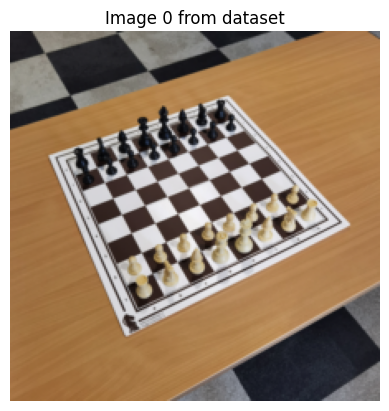

In [4]:
dataset = CornerDataset("/kaggle/input/dataset/dataset/annotations.json", "/kaggle/input/dataset/dataset/chessred2k/")
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

batch_size = 16

train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, collate_fn=lambda x: x, num_workers=4, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size, collate_fn=lambda x: x, num_workers=4, pin_memory=True)

# Get the first item
image, heatmaps = dataset[0]

# The image tensor is in (C, H, W), so we need to permute it to (H, W, C) for displaying
image_np = image.permute(1, 2, 0).numpy()

# Display the image
plt.imshow(image_np)
plt.title("Image 0 from dataset")
plt.axis('off')
plt.show()

In [5]:
class ResNetHeatmap(nn.Module):
    def __init__(self, backbone='resnet18', num_corners=4, heatmap_size=56):
        super(ResNetHeatmap, self).__init__()
        
        resnet = models.resnet18(weights='DEFAULT')
        self.features = nn.Sequential(*list(resnet.children())[:-2])  
        
        self.head = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 2, stride=2), nn.ReLU(),  
            nn.ConvTranspose2d(256, 128, 2, stride=2), nn.ReLU(),  
            nn.ConvTranspose2d(128, num_corners, 2, stride=2)      
        )

    
    def forward(self, x):
        x = self.features(x)
        x = self.head(x)
        return x  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetHeatmap().to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 116MB/s]


In [6]:
def one_epoch(model, optimizer, dataloader, loss_fn, is_training):
    model.train() if is_training else model.eval()
    avg_loss = 0.0

    for batch in dataloader:
        images = torch.stack([b[0] for b in batch]).to(device)
        targets = torch.stack([b[1] for b in batch]).to(device)

        with torch.set_grad_enabled(is_training):
            preds = model(images)  
            loss = loss_fn(preds, targets)  
            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        avg_loss += loss.item() / len(dataloader)
    return avg_loss


In [7]:
for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = nn.MSELoss()

epochs = 150
patience = 5
best_val_metric = float('inf')
best_epoch = 0

for epoch in range(epochs):
    train_loss = one_epoch(model, optimizer, train_dataloader, criterion, is_training=True)
    val_loss = one_epoch(model, optimizer, val_dataloader, criterion, is_training=False)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")    
    if val_loss < best_val_metric:
        best_val_metric = val_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    elif epoch - best_epoch >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best validation MPE: {best_val_metric:.4f}")
        break

model.load_state_dict(best_model_state)

Epoch 1, Train Loss: 0.006093, Val Loss: 0.004038
Epoch 2, Train Loss: 0.003916, Val Loss: 0.003836
Epoch 3, Train Loss: 0.003777, Val Loss: 0.003731
Epoch 4, Train Loss: 0.003670, Val Loss: 0.003630
Epoch 5, Train Loss: 0.003557, Val Loss: 0.003530
Epoch 6, Train Loss: 0.003454, Val Loss: 0.003450
Epoch 7, Train Loss: 0.003362, Val Loss: 0.003403
Epoch 8, Train Loss: 0.003277, Val Loss: 0.003330
Epoch 9, Train Loss: 0.003220, Val Loss: 0.003292
Epoch 10, Train Loss: 0.003167, Val Loss: 0.003227
Epoch 11, Train Loss: 0.003120, Val Loss: 0.003229
Epoch 12, Train Loss: 0.003069, Val Loss: 0.003209
Epoch 13, Train Loss: 0.003042, Val Loss: 0.003220
Epoch 14, Train Loss: 0.003016, Val Loss: 0.003162
Epoch 15, Train Loss: 0.002972, Val Loss: 0.003151
Epoch 16, Train Loss: 0.002955, Val Loss: 0.003180
Epoch 17, Train Loss: 0.002913, Val Loss: 0.003168
Epoch 18, Train Loss: 0.002892, Val Loss: 0.003169
Epoch 19, Train Loss: 0.002876, Val Loss: 0.003103
Epoch 20, Train Loss: 0.002876, Val Loss

<All keys matched successfully>

In [8]:
for param in model.features.parameters():
    param.requires_grad = True
    
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

epochs = 150
patience = 5
best_val_metric = float('inf')
best_epoch = 0

for epoch in range(epochs):
    train_loss = one_epoch(model, optimizer, train_dataloader, criterion, is_training=True)
    val_loss = one_epoch(model, optimizer, val_dataloader, criterion, is_training=False)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    # Early stopping
    
    if val_loss < best_val_metric:
        best_val_metric = val_loss
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
    elif epoch - best_epoch >= patience:
        print(f"Early stopping at epoch {epoch+1}. Best validation MPE: {best_val_metric:.4f}")
        break
    else:
        print(epoch-best_epoch)

model.load_state_dict(best_model_state)

Epoch 1, Train Loss: 0.002162, Val Loss: 0.001677
Epoch 2, Train Loss: 0.001440, Val Loss: 0.001379
Epoch 3, Train Loss: 0.001171, Val Loss: 0.001145
Epoch 4, Train Loss: 0.000945, Val Loss: 0.000946
Epoch 5, Train Loss: 0.000711, Val Loss: 0.000680
Epoch 6, Train Loss: 0.000472, Val Loss: 0.000473
Epoch 7, Train Loss: 0.000304, Val Loss: 0.000334
Epoch 8, Train Loss: 0.000206, Val Loss: 0.000266
Epoch 9, Train Loss: 0.000160, Val Loss: 0.000234
Epoch 10, Train Loss: 0.000130, Val Loss: 0.000203
Epoch 11, Train Loss: 0.000109, Val Loss: 0.000181
Epoch 12, Train Loss: 0.000096, Val Loss: 0.000165
Epoch 13, Train Loss: 0.000086, Val Loss: 0.000168
1
Epoch 14, Train Loss: 0.000076, Val Loss: 0.000150
Epoch 15, Train Loss: 0.000071, Val Loss: 0.000142
Epoch 16, Train Loss: 0.000067, Val Loss: 0.000139
Epoch 17, Train Loss: 0.000059, Val Loss: 0.000130
Epoch 18, Train Loss: 0.000054, Val Loss: 0.000127
Epoch 19, Train Loss: 0.000052, Val Loss: 0.000128
1
Epoch 20, Train Loss: 0.000047, Val 

<All keys matched successfully>

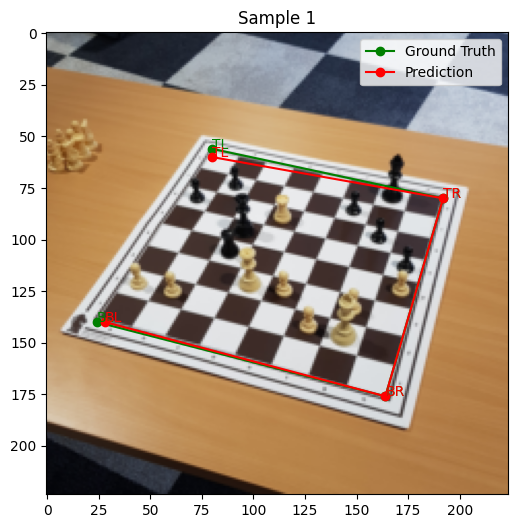

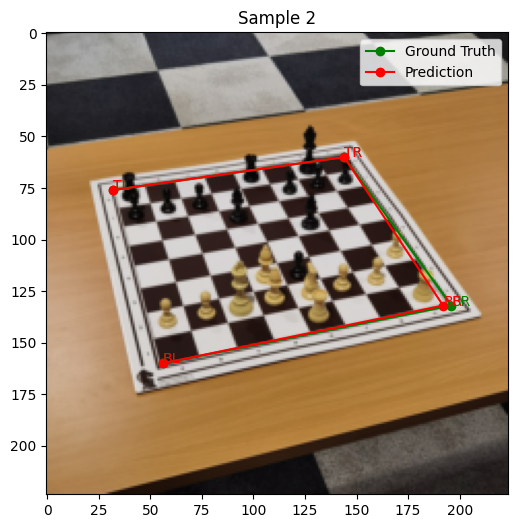

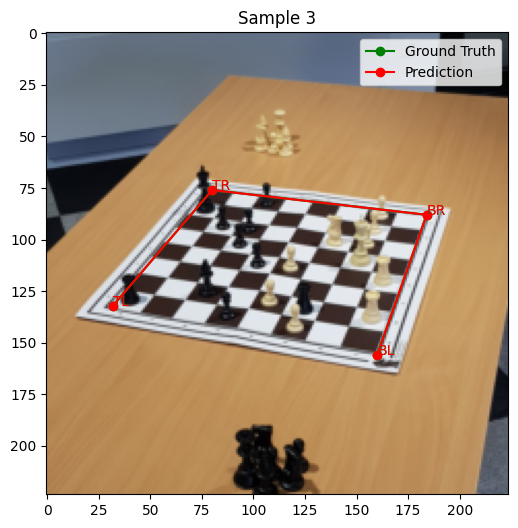

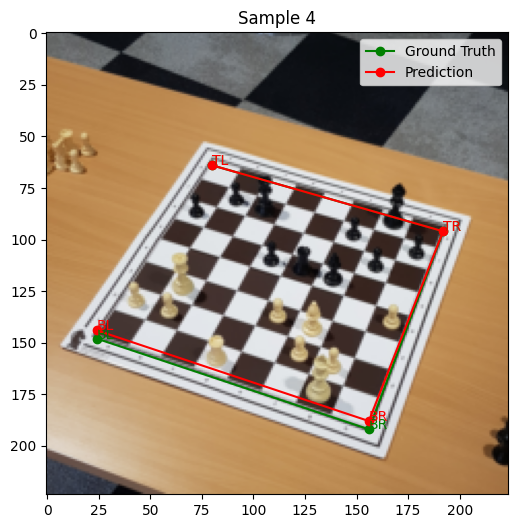

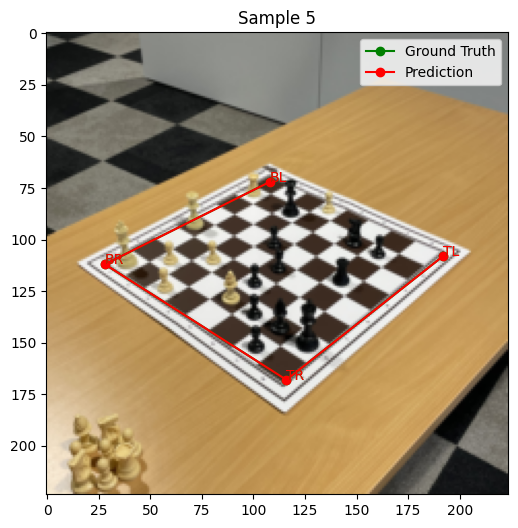

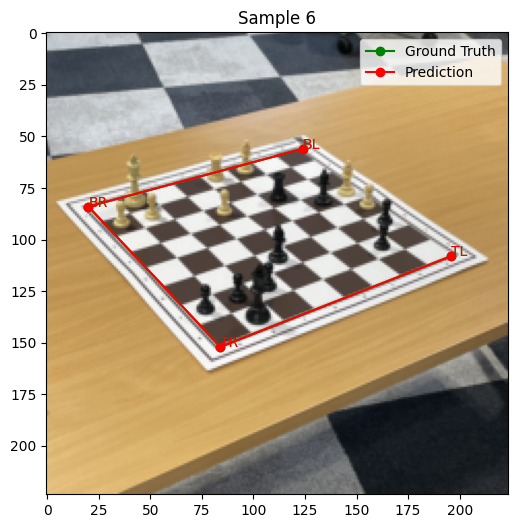

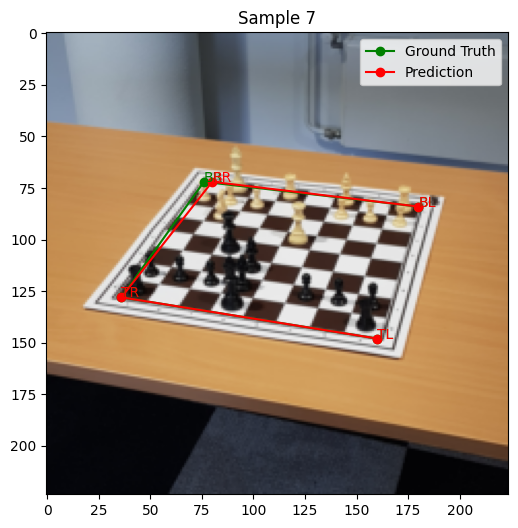

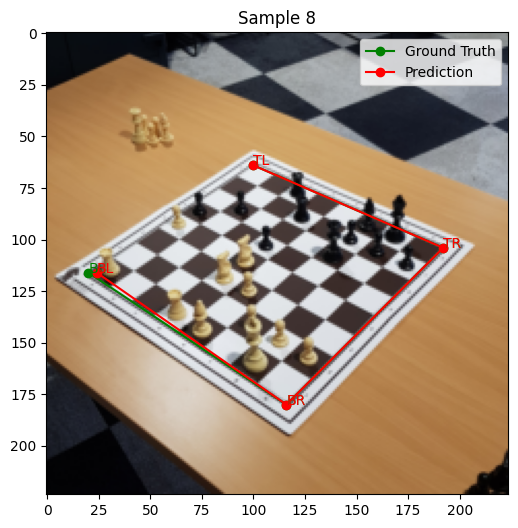

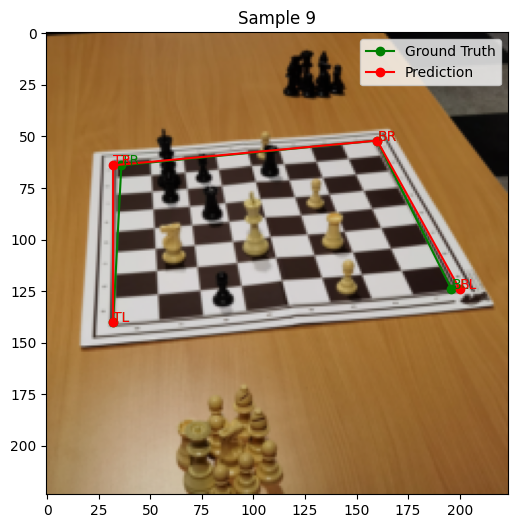

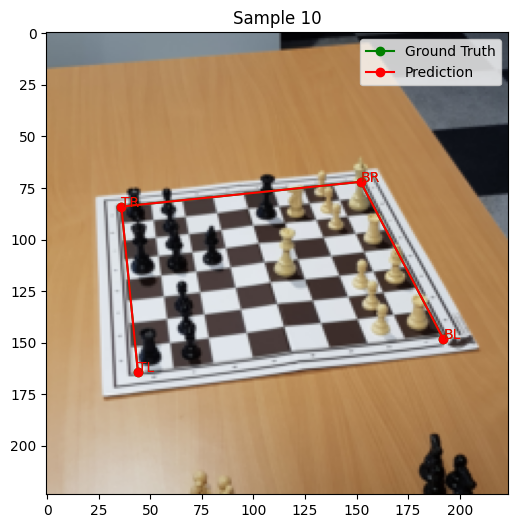

In [9]:
def heatmaps_to_points(heatmaps):
    num_corners, H, W = heatmaps.shape
    points = []

    for i in range(num_corners):
        heatmap = heatmaps[i]
        # Flatten and find argmax index
        max_val, idx = torch.max(heatmap.view(-1), dim=0)
        y, x = divmod(idx.item(), W)
        points.append((x, y))
    
    return points

def points_to_image_coordinates(points, heatmap_size, image_size=(224, 224)):
    img_w, img_h = image_size
    scale_x = img_w / heatmap_size
    scale_y = img_h / heatmap_size
    
    image_points = [
        (x * scale_x, y * scale_y) for (x, y) in points
    ]
    
    return image_points

def visualize_predictions(model, dataset, num_samples=5, image_size=224, heatmap_size=56):
    model.eval()
    
    for i in range(num_samples):
        image, gt_heatmaps = dataset[i]
        input_image = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred_heatmaps = model(input_image).cpu().squeeze(0)

        pred_points_hm = heatmaps_to_points(pred_heatmaps)
        pred_points_img = points_to_image_coordinates(pred_points_hm, heatmap_size, (image_size, image_size))

        gt_points_hm = heatmaps_to_points(gt_heatmaps)
        gt_points_img = points_to_image_coordinates(gt_points_hm, heatmap_size, (image_size, image_size))

        image_np = image.permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(1, figsize=(6, 6))
        ax.imshow(image_np)

        gt_points_np = np.array(gt_points_img)
        ax.plot(gt_points_np[:, 0], gt_points_np[:, 1], 'go-', label='Ground Truth')

        pred_points_np = np.array(pred_points_img)
        ax.plot(pred_points_np[:, 0], pred_points_np[:, 1], 'ro-', label='Prediction')

        for j, txt in enumerate(['TL', 'TR', 'BR', 'BL']):
            ax.annotate(txt, (gt_points_np[j][0], gt_points_np[j][1]), color='green')
            ax.annotate(txt, (pred_points_np[j][0], pred_points_np[j][1]), color='red')

        ax.legend()
        ax.set_title(f"Sample {i+1}")
        plt.show()


# Now call it:
visualize_predictions(model, val_dataloader.dataset, num_samples=10)
